# Import Packages

In [1286]:
import math
import random
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

# Helpers / toy distributions

In [1287]:
def sigmoid(x: float) -> float:
    return 1.0 / (1.0 + math.exp(-x))

def clamp(x: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, x))

# -----------------------------
# Models you can swap
# -----------------------------

def sample_auction() -> Dict:
    """
    One incoming auction (impression opportunity).
    Replace with your own feature sampling / replay logs.
    """
    # toy: "quality" drives both pCTR and price competitiveness
    q = random.gauss(0.0, 1.0)
    return {"q": q}

def pctr_model(auction: Dict) -> float:
    """Toy pCTR. Replace with your model."""
    return clamp(sigmoid(0.8 * auction["q"]), 1e-4, 0.2)

def value_per_click() -> float:
    """Toy value per click (could be CPA target, revenue, etc.)."""
    return 1.0  # arbitrary units

def base_bid_from_value(pctr: float, v_click: float) -> float:
    """
    Base bid policy without pacing.
    For CPC: bid ~ pCTR * value_per_click (or something monotone).
    For CPA: bid ~ pCVR * value_per_conv * ...
    """
    return pctr * v_click

def base_bid_for_tcpa(pctr:float, pcvr: float, tcpa: float) -> float:
    """
    Base bid policy without pacing.
    For CPC: bid ~ pCTR * value_per_click (or something monotone).
    For CPA: bid ~ pCVR * value_per_conv * ...
    """
    return pctr * pcvr * tcpa
    
def win_prob(bid: float, auction: Dict) -> float:
    """
    Bid landscape / win rate model: P(win | bid, context).
    Toy: more competitive when q is high (harder to win).
    Replace with: logistic on log(bid) - log(market_price) etc.
    """
    competitiveness = 0.5 * auction["q"] + 0.8 * (auction.get("demand_mult", 1.0) - 1.0)
    return clamp(sigmoid(3.0 * math.log(1.0 + bid) - competitiveness), 0.0, 1.0)
    
def clearing_price(bid: float, auction: Dict) -> float:
    """
    If you win, what do you pay? (2nd price proxy)
    Toy: pay some fraction of bid, plus context noise.
    Replace with sampled market price conditional on context.
    """
    dm = auction.get("demand_mult", 1.0)
    noise = random.uniform(0.3, 0.7)
    return bid * noise * (0.9 + 0.2 * dm)  # pays a bit more at peaks

# Simulate pCVR and conversion delay 

In [1288]:
# tCPA/conversion-delayed pacing
def pcvr_model(auction: dict) -> float:
    """
    Toy pCVR model.
    In practice: pCVR = f(features).
    """
    return clamp(0.02 * sigmoid(auction["q"]), 1e-4, 0.2)

def sample_conversion_delay() -> int:
    """
    Heavy-tailed delay (very common in ads).
    Returns delay in minutes.
    """
    # log-normal style delay
    delay_hours = max(0.01, random.lognormvariate(mu=1.0, sigma=1.0))
    return int(delay_hours * 60)

## Mental model:
# from collections import defaultdict
# conversion_events = defaultdict(int)
# fire_minute = t + delay
# conversion_events[fire_minute] += 1
# observed_conversions += conversion_events[t]

# expected_conversions_so_far += pctr * pcvr

# Simulate spend curve

In [1289]:

def linear_spend_curve(total_budget: float, t: int, T: int) -> float:
    """
    Target cumulative spend by time t (0..T).
    Swap with: intraday curve, learned curve, front-load/back-load.
    """
    frac = t / max(1, T)
    return total_budget * frac


def back_loading_spend_curve(total_budget: float, t: int, T: int, alpha: float = 2.0) -> float:
    """
    Target cumulative spend by time t (0..T).
    Swap with: intraday curve, learned curve, front-load/back-load.
    """
    frac = (t / max(1, T))
    return total_budget * (frac**alpha)

def front_loading_spend_curve(total_budget: float, t: int, T: int, alpha: float = 2.0) -> float:
    """
    Target cumulative spend by time t (0..T).
    Swap with: intraday curve, learned curve, front-load/back-load.
    """
    frac = (t / max(1, T))
    return total_budget * (frac**(1/alpha))

def logistic_curve(total_budget: float, t: int, T: int, k: float = 5.0) -> float:
    """
    k controls steepness of mid-day ramp
    """
    x = (t / T) * 2 - 1  # map to [-1, 1]
    s = 1.0 / (1.0 + math.exp(-k * x))
    s0 = 1.0 / (1.0 + math.exp(k))     # normalize to start at 0
    s1 = 1.0 / (1.0 + math.exp(-k))    # end at 1
    frac = (s - s0) / (s1 - s0)
    return total_budget * frac

# Simulate Hourly Demand

In [1290]:
def demand_multiplier(minute_of_day: int) -> float:
    """
    Returns a multiplier on auction arrival rate based on minute-of-day [0, 1440).
    Tune these numbers to match your market.
    """
    h = (minute_of_day // 60) % 24

    # Very simple piecewise profile
    if 0 <= h < 6:   # overnight low
        return 0.35
    if 6 <= h < 9:   # morning ramp
        return 0.70
    if 9 <= h < 12:  # late morning
        return 1.00
    if 12 <= h < 15: # midday peak
        return 1.25
    if 15 <= h < 18: # afternoon
        return 1.10
    if 18 <= h < 22: # evening peak
        return 1.30
    return 0.60      # late night

def make_spend_curve_matched_to_demand(demand_mult_fn, day_minutes: int = 1440):
    """
    Returns a spend_curve(B, t, T) that matches target spend to the demand curve.
    - demand_mult_fn(minute_of_day)->multiplier (>=0)
    - Uses a precomputed cumulative weight table for speed.
    """

    # Precompute weights for one day
    w = [max(0.0, float(demand_mult_fn(m))) for m in range(day_minutes)]
    prefix = [0.0] * (day_minutes + 1)
    for i in range(day_minutes):
        prefix[i + 1] = prefix[i] + w[i]
    day_total = prefix[-1] if prefix[-1] > 0 else 1.0

    def spend_curve(total_budget: float, t: int, T: int) -> float:
        """
        Target cumulative spend by minute t (1..T).
        Assumes T is within a day; if your horizon spans multiple days,
        this repeats the daily pattern.
        """
        # integrate weights over minutes [0, t)
        # If horizon can exceed 1440, we repeat daily pattern.
        minutes = max(0, int(t))
        full_days = minutes // day_minutes
        rem = minutes % day_minutes

        cum_w = full_days * day_total + prefix[rem]

        # total weight over [0, T)
        total_minutes = max(1, int(T))
        full_days_T = total_minutes // day_minutes
        rem_T = total_minutes % day_minutes
        total_w = full_days_T * day_total + prefix[rem_T]
        if total_w <= 0:
            total_w = 1.0

        frac = cum_w / total_w
        return total_budget * frac

    return spend_curve

# Simulate 2nd market price

In [1291]:
def sample_market_price(auction: Dict) -> float:
    """
    Proxy for clearing price distribution conditional on context.
    Higher q and higher demand => higher market price.
    """
    dm = auction.get("demand_mult", 1.0)

    # lognormal market price; tune these
    mu = 0.2 * auction["q"] + 0.4 * math.log(dm)  # shift with context
    sigma = 0.5

    # ensure positive
    return max(0.01, 0.3*random.lognormvariate(mu=mu, sigma=sigma))

def win_and_price(bid: float, auction: Dict) -> tuple[bool, float]:
    mkt = sample_market_price(auction)
    if bid >= mkt:
        return True, mkt   # 2nd-price-ish: pay clearing price
    return False, 0.0

# Pacing controller

In [1292]:
@dataclass
class PacingConfig:
    # pacing multiplier bounds
    mult_min: float = 0.3
    mult_max: float = 3.0

    # update rule parameters (simple PI-like)
    kp: float = 0.7
    ki: float = 0.05

    # anti-windup clamp on integral term
    integ_min: float = -5.0
    integ_max: float = 5.0

    # smoothing on multiplier updates
    smooth: float = 0.2  # 0..1, higher = faster changes

@dataclass
class PacingState:
    multiplier: float = 1.0
    integ_err: float = 0.0

def update_pacing_multiplier(
    cfg: PacingConfig,
    st: PacingState,
    target_spend_so_far: float,
    actual_spend_so_far: float,
) -> float:
    """
    Control objective: track cumulative spend curve.
    error > 0 => behind => increase multiplier.
    """
    # normalize error to avoid scaling headaches
    denom = max(1e-6, target_spend_so_far)
    err = (target_spend_so_far - actual_spend_so_far) / denom  # + means behind

    st.integ_err = clamp(st.integ_err + err, cfg.integ_min, cfg.integ_max)

    raw = 1.0 + cfg.kp * err + cfg.ki * st.integ_err
    raw = clamp(raw, cfg.mult_min, cfg.mult_max)

    # smooth multiplicative changes (EMA in multiplier space)
    st.multiplier = (1.0 - cfg.smooth) * st.multiplier + cfg.smooth * raw
    st.multiplier = clamp(st.multiplier, cfg.mult_min, cfg.mult_max)
    return st.multiplier

# Turn pacing mult to throttler.
def pacing_mult_to_enter_prob(pacing_mult: float, k: float = 2.0, p_at_1: float = 0.9) -> float:
    """
    Set p_at_1 to control baseline participation.
    """
    x = math.log(max(1e-6, pacing_mult))
    # choose bias so that when x=0 => p=p_at_1
    b = math.log(p_at_1 / (1.0 - p_at_1))
    return 1.0 / (1.0 + math.exp(-(b + k * x)))

# tCPA controller

In [1293]:
@dataclass
class TCPAConfig:
    target_cpa: float = 10.0
    cpa_kp: float = 0.5
    cpa_clip: float = 0.5

def cpa_adjustment(
    spent: float,
    expected_convs: float,
    cfg: TCPAConfig,
) -> float:
    if expected_convs <= 1e-6:
        return 1.0

    est_cpa = spent / expected_convs
    err = (cfg.target_cpa - est_cpa) / cfg.target_cpa
    err = clamp(err, -cfg.cpa_clip, cfg.cpa_clip)

    return 1.0 + cfg.cpa_kp * err

def cpa_ratio_multiplier(spent: float, expected_convs: float, target_cpa: float,
                         gamma: float = 1, mult_min: float = 0.1, mult_max: float = 3.0) -> float:
    """
    gamma in (0,1]: smaller = gentler. Start with 0.3~0.7.
    """
    est_cpa = spent / max(1e-6, expected_convs)
    ratio = target_cpa / max(1e-6, est_cpa)   # >1 => CPA too low => bid up
    return clamp(ratio ** gamma, mult_min, mult_max)
    # desired_spend = target_cpa * expected_convs
    # ratio = desired_spend / max(1e-6, spent)   # >1 means we're "too cheap" (CPA below target)
    # mult = ratio ** gamma
    # return clamp(mult, mult_min, mult_max)

def smooth_mult(prev: float, raw: float, smooth: float = 0.1) -> float:
    # smooth in log-space is usually nicer
    prev_l = math.log(prev)
    raw_l = math.log(max(1e-6, raw))
    out = math.exp((1 - smooth) * prev_l + smooth * raw_l)
    return out

# Simulation core

In [1294]:
@dataclass
class SimConfig:
    seed: int = 7

    # timeline
    horizon_minutes: int = 24 * 60
    auctions_per_minute: int = 200  # average supply rate

    # money
    total_budget: float = 10000.0  # total spend cap
    stop_when_budget_exhausted: bool = True

    # bid clamps
    bid_min: float = 0.0
    bid_max: float = 20

    # bid scale
    bid_scale: float = 3.0

from collections import defaultdict

def run_sim(
    sim: SimConfig,
    pacing_cfg: PacingConfig,
    spend_curve: Callable[[float, int, int], float] = lambda B, t, T: logistic_curve(B, t, T, k=3),
) -> Dict:
    random.seed(sim.seed)

    st = PacingState(multiplier=1.0, integ_err=0.0)

    spent = 0.0
    wins = 0
    auctions = 0
    clicks = 0
    
    expected_conversions = 0
    T = sim.horizon_minutes
    cpa_mult_ema = 1.0  
    pacing_mult = 1.0

    # time series for plotting later
    ts: List[Dict] = []
    wins_list = []  # list of per-win records

    for t in range(1, T + 1):
        target_cum = spend_curve(sim.total_budget, t, T)

        # controller updates once per minute (common in practice)
        if t % 5 == 0:
            pacing_mult = update_pacing_multiplier(pacing_cfg, st, target_cum, spent)
        enter_prob = pacing_mult_to_enter_prob(pacing_mult, k=2.0, p_at_1=0.95)
        minute_of_day = (t - 1) % 1440
        dm = demand_multiplier(minute_of_day)  # or demand_multiplier_smooth(...)
        auctions_this_minute = max(0, int(round(sim.auctions_per_minute * dm)))

        minute_spend = 0.0
        minute_wins = 0
        minute_clicks = 0
        total_pctr = 0.0
        total_pcvr = 0.0
        max_bid_capped = 0
        entered = 0
        for _ in range(auctions_this_minute):
            if sim.stop_when_budget_exhausted and spent >= sim.total_budget:
                break

            auction = sample_auction()
            pctr = pctr_model(auction)
            pcvr = pcvr_model(auction)
            total_pctr += pctr
            total_pcvr += pcvr

            # probabilistic throttling
            if random.random() > enter_prob:
                continue
            entered += 1
            base_bid = sim.bid_scale*base_bid_for_tcpa(pctr, pcvr, tcpa_cfg.target_cpa)
            # cpa_mult = cpa_adjustment(spent, expected_conversions, tcpa_cfg)
            if expected_conversions < 5.0:
                cpa_mult = 1.0
            else:
                if t % 15 == 0:
                    raw_cpa_mult = cpa_ratio_multiplier(spent, expected_conversions, tcpa_cfg.target_cpa, gamma=0.8, mult_min=0.3, mult_max=3.0)
                    cpa_mult_ema = smooth_mult(cpa_mult_ema, raw_cpa_mult, smooth=0.05)  # try 0.02~0.1
                cpa_mult = cpa_mult_ema
            bid = clamp(base_bid * cpa_mult, sim.bid_min, sim.bid_max)
            if(sim.bid_max-bid < 1e-6):
                max_bid_capped += 1
            auctions += 1

            # decide win
            won, price = win_and_price(bid, auction)
            if won:
                # price = clearing_price(bid, auction)
                # budget cap enforcement at impression-level
                if spent + price > sim.total_budget and sim.stop_when_budget_exhausted:
                    continue
                
                wins_list.append({
                    "price": price,
                    "expected_conv": pctr * pcvr,
                    "minute": t,
                    "bid": bid,
                })
                expected_conversions += pctr * pcvr

                spent += price
                minute_spend += price
                wins += 1
                minute_wins += 1

                # click realization
                if random.random() < pctr:
                    clicks += 1
                    minute_clicks += 1
                    # conversion realization
                    if random.random() < pcvr:
                        delay = sample_conversion_delay()
                        conversion_events[t + delay] += 1
        expected_cpa = spent / max(1e-6, expected_conversions)
        ts.append(
            {
                "t_min": t,
                "target_cum_spend": target_cum,
                "actual_cum_spend": spent,
                "minute_spend": minute_spend,
                "pacing_mult": pacing_mult,
                "cpa_mult": cpa_mult,
                "minute_wins": minute_wins,
                "minute_clicks": minute_clicks,
                "auction_arrivals": auctions_this_minute,
                "expected_conversions": expected_conversions,
                "avg_pctr": total_pctr/auctions_this_minute,
                "avg_pcvr": total_pcvr/auctions_this_minute,
                "demand_mult": dm,
                "expected_cpa": expected_cpa,
                "max_bid_capped": max_bid_capped,
                "enter_prob": enter_prob,
                "entered": entered,
                "entry_rate": entered / max(1, auctions_this_minute),
            }
        )

        if sim.stop_when_budget_exhausted and spent >= sim.total_budget:
            # still record that we're exhausted and stop
            break
    return {
        "summary": {
            "spent": spent,
            "budget": sim.total_budget,
            "auctions": auctions,
            "wins": wins,
            "clicks": clicks,
            "win_rate": wins / max(1, auctions),
            "ctr_on_wins": clicks / max(1, wins),
            "minutes_simulated": ts[-1]["t_min"] if ts else 0,
        },
        "timeseries": ts,
        "wins_list": wins_list,
    }

# Example run

In [1295]:
# Parameters to tune
total_budget = 30000.0
target_cpa = 100
cpa_clip = 0.8
bid_scale = 2

In [1296]:
if __name__ == "__main__":
    sim_cfg = SimConfig(
        seed=42,
        horizon_minutes=24 * 60,
        auctions_per_minute=500,
        total_budget=total_budget,
        bid_scale = bid_scale,
    )
    pacing_cfg = PacingConfig(kp=0.95, ki=0.2, smooth=0.2, mult_min=0.02, mult_max=5.0)
    tcpa_cfg = TCPAConfig(target_cpa = target_cpa, cpa_kp = 0.6, cpa_clip = cpa_clip)
    spend_curve = make_spend_curve_matched_to_demand(demand_multiplier)
    conversion_events = defaultdict(int)
    out = run_sim(sim_cfg, pacing_cfg, spend_curve)

    print("Summary:", out["summary"])

Summary: {'spent': 29999.993821601336, 'budget': 30000.0, 'auctions': 204706, 'wins': 114337, 'clicks': 22896, 'win_rate': 0.55854249509052, 'ctr_on_wins': 0.20025013775068437, 'minutes_simulated': 1440}


# Plot out timeseries using matplotlib/pandas.

In [1297]:
import matplotlib.pyplot as plt
from typing import Dict

def plot(out: Dict) -> None:
    ts = out["timeseries"]

    t = [x["t_min"] for x in ts]
    target = [x["target_cum_spend"] for x in ts]
    actual = [x["actual_cum_spend"] for x in ts]
    pacing_mult = [x["pacing_mult"] for x in ts]
    cpa_mult = [x["cpa_mult"] for x in ts]
    minute_spend = [x["minute_spend"] for x in ts]

    # -----------------------------
    # 1. Target vs Actual Spend
    # -----------------------------
    plt.figure()
    plt.plot(t, target, label="Target Cumulative Spend")
    plt.plot(t, actual, label="Actual Cumulative Spend")
    plt.xlabel("Minute")
    plt.ylabel("Spend")
    plt.title("Budget Pacing: Target vs Actual Spend")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 2.1 Pacing Multiplier
    # -----------------------------
    plt.figure()
    plt.plot(t, pacing_mult)
    plt.xlabel("Minute")
    plt.ylabel("Pacing Multiplier")
    plt.title("Pacing Multiplier Over Time")
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 2.2 tCPA Multiplier
    # -----------------------------
    plt.figure()
    plt.plot(t, cpa_mult)
    plt.xlabel("Minute")
    plt.ylabel("CPA Multiplier")
    plt.title("CPA multiplier Over Time")
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 3. Minute-Level Spend
    # -----------------------------
    plt.figure()
    plt.plot(t, minute_spend)
    plt.xlabel("Minute")
    plt.ylabel("Spend per Minute")
    plt.title("Minute-Level Spend (Oscillation View)")
    plt.grid(True)
    plt.show()



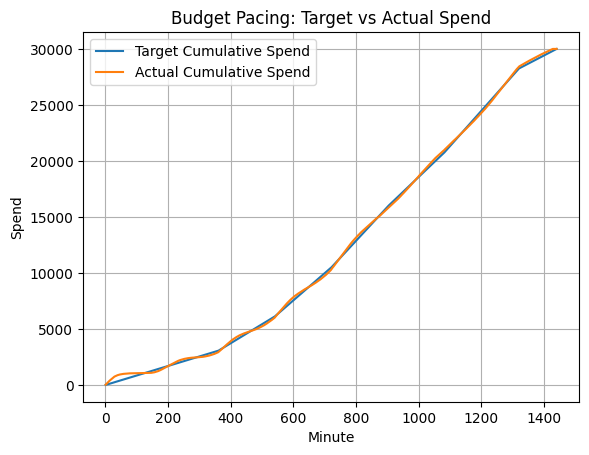

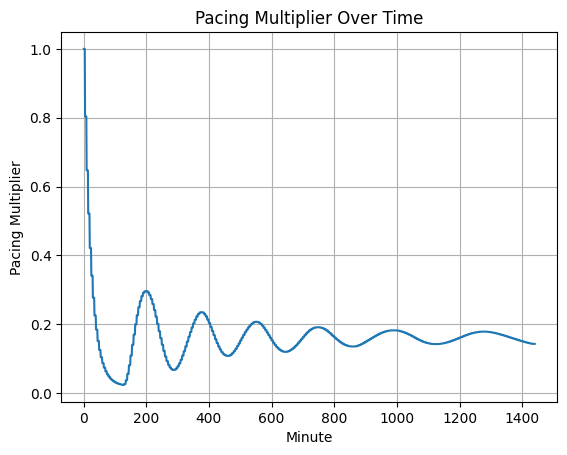

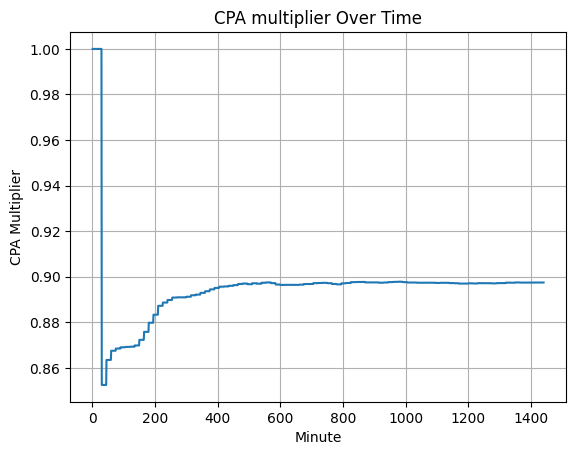

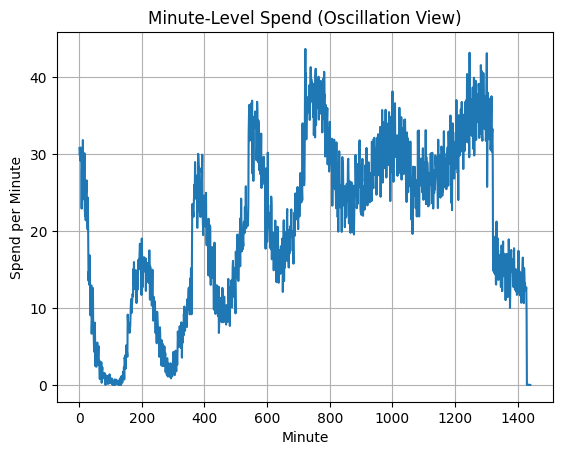

In [1298]:
plot(out)

# Plot hourly spend curve matched to the demand curve

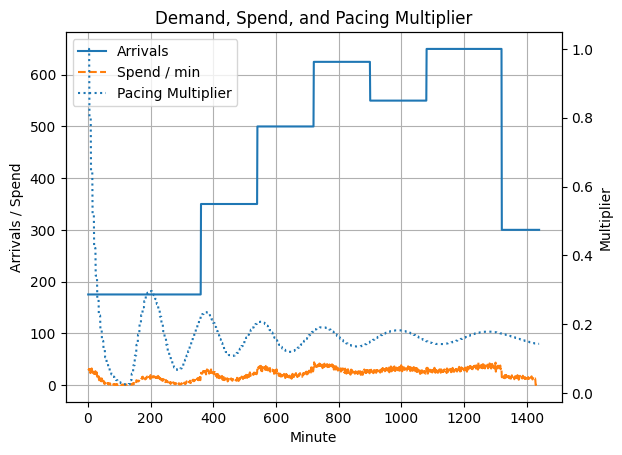

In [1299]:
import matplotlib.pyplot as plt

ts = out["timeseries"]

t = [x["t_min"] for x in ts]
arrivals = [x["auction_arrivals"] for x in ts]
minute_spend = [x["minute_spend"] for x in ts]
mult = [x["pacing_mult"] for x in ts]

fig, ax1 = plt.subplots()

ax1.plot(t, arrivals, label="Arrivals")
ax1.plot(t, minute_spend, linestyle="--", label="Spend / min")
ax1.set_xlabel("Minute")
ax1.set_ylabel("Arrivals / Spend")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(t, mult, linestyle=":", label="Pacing Multiplier")
ax2.set_ylabel("Multiplier")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Demand, Spend, and Pacing Multiplier")
plt.show()

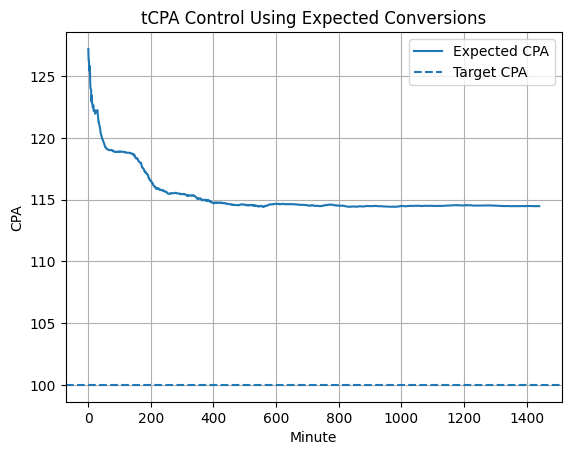

In [1300]:
# CPA over time (expected vs observed)
est_cpa = [
    x["actual_cum_spend"] / max(1e-6, x["expected_conversions"])
    for x in ts
]

# expected_convs = [
#     x["expected_conversions"]
#     for x in ts
# ]

# print(expected_convs[:100])

plt.figure()
plt.plot(t, est_cpa, label="Expected CPA")
plt.axhline(tcpa_cfg.target_cpa, linestyle="--", label="Target CPA")
plt.xlabel("Minute")
plt.ylabel("CPA")
plt.title("tCPA Control Using Expected Conversions")
plt.legend()
plt.grid(True)
plt.show()

# Plot pCTR, pCVR, Conversion Count and CPC

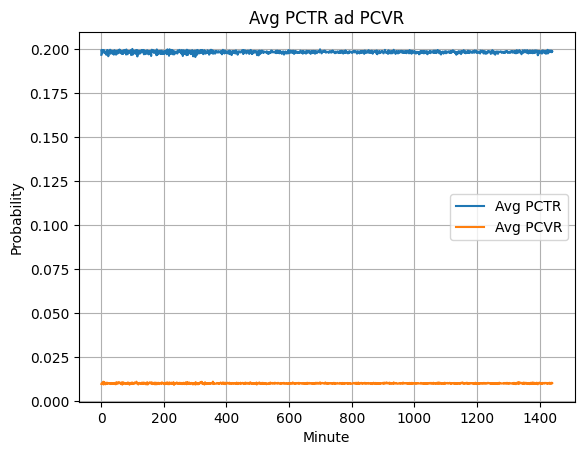

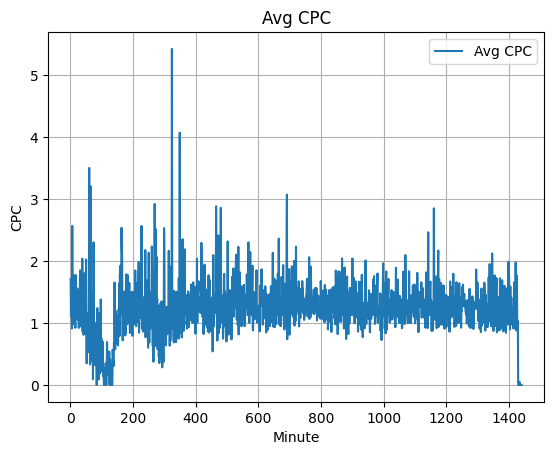

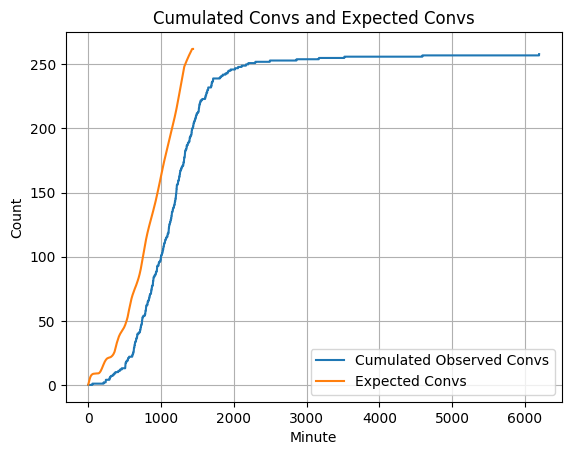

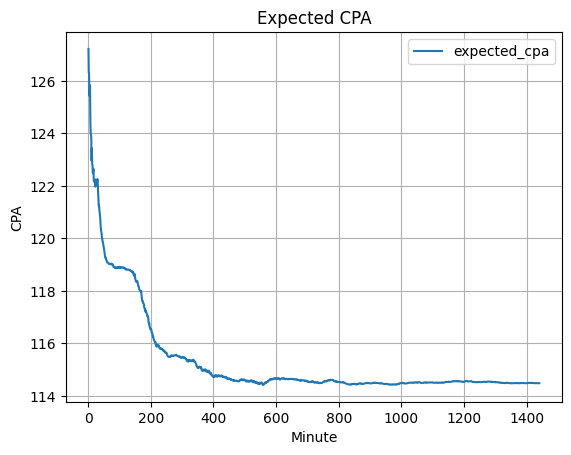

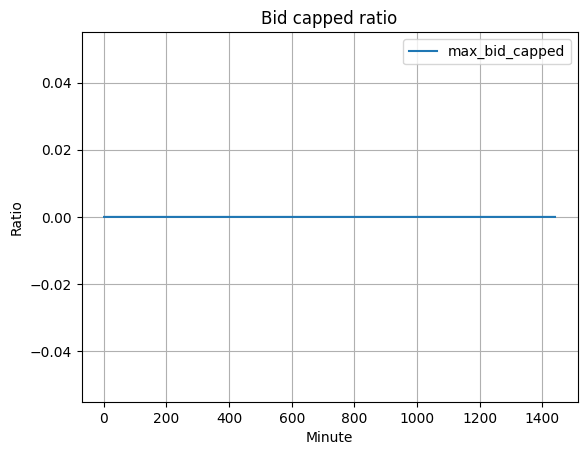

In [1301]:
avg_pctrs = [
    x["avg_pctr"]
    for x in ts
]

avg_pcvrs = [
    x["avg_pcvr"]
    for x in ts
]

plt.figure()
plt.plot(t, avg_pctrs, label="Avg PCTR")
plt.plot(t, avg_pcvrs, label="Avg PCVR")
plt.xlabel("Minute")
plt.ylabel("Probability")
plt.title("Avg PCTR ad PCVR")
plt.legend()
plt.grid(True)
plt.show()


minute_cpc = [float(x["minute_spend"])/(x["minute_clicks"]+1) for x in ts]
plt.figure()
plt.plot(t, minute_cpc, label="Avg CPC")
plt.xlabel("Minute")
plt.ylabel("CPC")
plt.title("Avg CPC")
plt.legend()
plt.grid(True)
plt.show()

###
expected_conversions = [x["expected_conversions"] for x in ts]
# Convert defaultdict to list
# 1. Determine the required length (max key + 1)
size = max(conversion_events.keys()) + 1
# 2. Initialize with a placeholder 
cumulated_convs = [0] * size
# 3. Fill the list
cumulated_conv = 0

for i in range(size):
    cumulated_conv += conversion_events.get(i, 0)
    cumulated_convs[i] = cumulated_conv
t_conv = range(size)

plt.figure()
plt.plot(t_conv, cumulated_convs, label="Cumulated Observed Convs")
plt.plot(t, expected_conversions, label="Expected Convs")
plt.xlabel("Minute")
plt.ylabel("Count")
plt.title("Cumulated Convs and Expected Convs")
plt.legend()
plt.grid(True)
plt.show()

# Expected cpa
expected_cpa = [x["expected_cpa"] for x in ts]
plt.figure()
plt.plot(t, expected_cpa, label="expected_cpa")
plt.xlabel("Minute")
plt.ylabel("CPA")
plt.title("Expected CPA")
plt.legend()
plt.grid(True)
plt.show()

# max_bid_capped
max_bid_capped_ratio = [float(x["max_bid_capped"])/x["auction_arrivals"] for x in ts]
plt.figure()
plt.plot(t, max_bid_capped_ratio, label="max_bid_capped")
plt.xlabel("Minute")
plt.ylabel("Ratio")
plt.title("Bid capped ratio")
plt.legend()
plt.grid(True)
plt.show()

# Plot entered, enter_rate and enter_prob

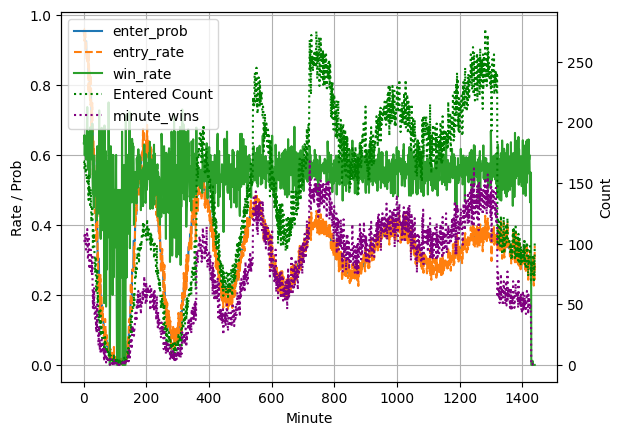

In [1302]:
entered = [x["entered"] for x in ts]
enter_prob = [x["enter_prob"] for x in ts]
entry_rate = [x["entry_rate"] for x in ts]
minute_wins = [x["minute_wins"] for x in ts]
win_rate = [x["minute_wins"]/(x["entered"]+1) for x in ts]

fig, ax1 = plt.subplots()

ax1.plot(t, enter_prob, label="enter_prob")
ax1.plot(t, entry_rate, linestyle="--", label="entry_rate")
ax1.plot(t, win_rate, label="win_rate")
ax1.set_xlabel("Minute")
ax1.set_ylabel("Rate / Prob")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(t, entered, linestyle=":", label="Entered Count", color="green")
ax2.plot(t, minute_wins, linestyle=":", label="minute_wins", color="purple")
ax2.set_ylabel("Count")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Plot CPA vs cumulative spend percentile:

[{'price': 0.15700747109072377, 'expected_conv': 0.00182752587131264, 'minute': 1, 'bid': 0.36550517426252804}, {'price': 0.36625405439376374, 'expected_conv': 0.003436962333107651, 'minute': 1, 'bid': 0.6873924666215302}, {'price': 0.21458154816631766, 'expected_conv': 0.0028000533922082982, 'minute': 1, 'bid': 0.5600106784416596}, {'price': 0.19025950787068518, 'expected_conv': 0.0010740341613622738, 'minute': 1, 'bid': 0.21480683227245476}]


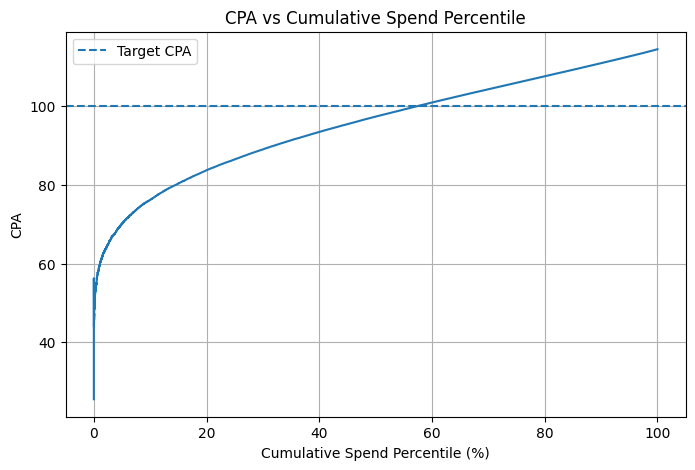

In [1303]:
import numpy as np
import matplotlib.pyplot as plt

wins_list = out["wins_list"]
print(wins_list[1:5])

# sort by price (cheap inventory first)
wins_sorted = sorted(wins_list, key=lambda x: x["price"])

prices = np.array([w["price"] for w in wins_sorted])
econvs = np.array([w["expected_conv"] for w in wins_sorted])

cum_spend = np.cumsum(prices)
cum_convs = np.cumsum(econvs)

# guard against zero
cpa_curve = cum_spend / np.maximum(1e-6, cum_convs)

spend_percentile = cum_spend / cum_spend[-1] * 100

plt.figure(figsize=(8, 5))
plt.plot(spend_percentile, cpa_curve)
plt.axhline(tcpa_cfg.target_cpa, linestyle="--", label="Target CPA")
plt.xlabel("Cumulative Spend Percentile (%)")
plt.ylabel("CPA")
plt.title("CPA vs Cumulative Spend Percentile")
plt.legend()
plt.grid(True)
plt.show()